In [139]:
import torch
torch.__version__

'2.5.1+cu121'

In [140]:
weight = 0.3
bias = 0.9 
start = 0.01
end = 2
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = X*weight+bias

y[:10]

tensor([[0.9030],
        [0.9090],
        [0.9150],
        [0.9210],
        [0.9270],
        [0.9330],
        [0.9390],
        [0.9450],
        [0.9510],
        [0.9570]])

In [141]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [142]:
import matplotlib.pyplot as plt

def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=None):
    plt.figure(figsize=(10,7))
    plt.scatter(train_data,train_labels,c='b',label='Training data')
    plt.scatter(test_data,test_labels,c='g',label="Testing data")
    if predictions is not None:
        plt.scatter(test_data,predictions,c='r',label='Predicted values')
    plt.legend(prop={'size':14})

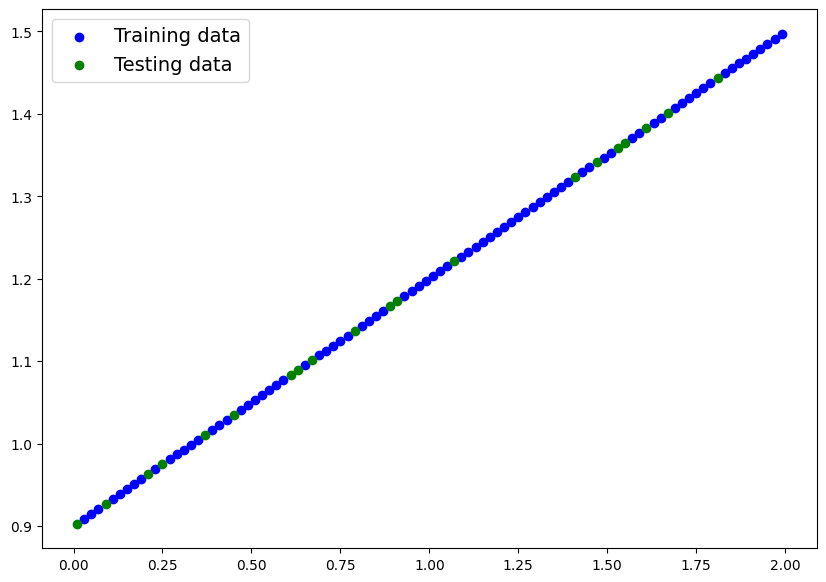

In [143]:
plot_predictions()

In [144]:
from torch import nn
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)
        self.bias   = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)
    
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.weight*x+self.bias

In [145]:
torch.manual_seed(42)
model_0 = LinearModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

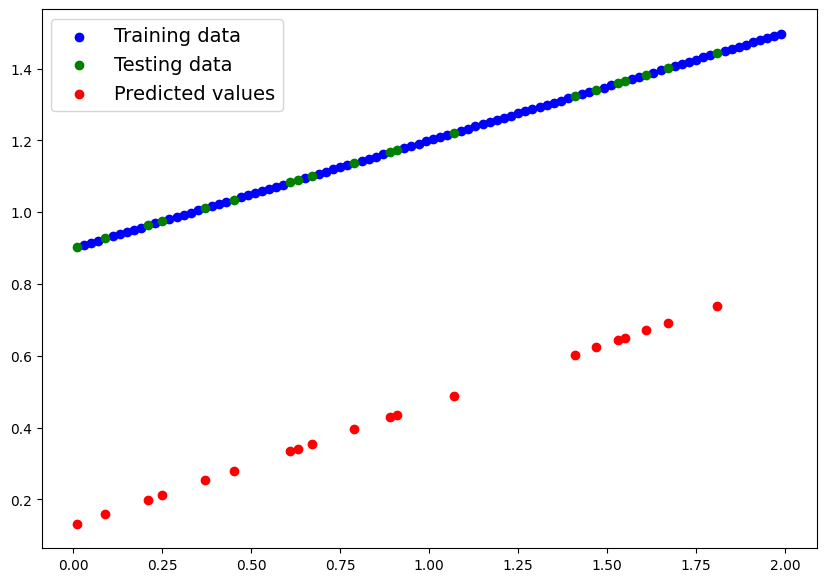

In [146]:
with torch.inference_mode():
    y_pred = model_0(x_test)
y_pred[:10]
plot_predictions(predictions=y_pred)

In [147]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_0.parameters(),lr=0.01)

In [148]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [149]:
torch.manual_seed(32)
epochs_data = []
train_loss_values = []
test_loss_values = []

epochs = 1000
loss_fn = torch.nn.L1Loss()  # MAE loss

for e in range(epochs):
    model_0.train()
    y_pred = model_0(x_train)
    loss = loss_fn(y_pred, y_train.type(torch.float))  # Consistent type
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    model_0.eval()
    with torch.inference_mode():
        test_pred = model_0(x_test)
        test_loss = loss_fn(test_pred, y_test.type(torch.float))
        
        if e % 10 == 0:
            epochs_data.append(e)
            train_loss_values.append(loss.item())  # Use .item()
            test_loss_values.append(test_loss.item())
            print(f"epochs:{e} | MAE train loss: {loss.item():.4f} | MAE test loss: {test_loss.item():.4f}")

epochs:0 | MAE train loss: 0.7336 | MAE test loss: 0.7189
epochs:10 | MAE train loss: 0.5285 | MAE test loss: 0.5267
epochs:20 | MAE train loss: 0.3235 | MAE test loss: 0.3344
epochs:30 | MAE train loss: 0.2035 | MAE test loss: 0.2170
epochs:40 | MAE train loss: 0.1795 | MAE test loss: 0.1970
epochs:50 | MAE train loss: 0.1666 | MAE test loss: 0.1849
epochs:60 | MAE train loss: 0.1559 | MAE test loss: 0.1731
epochs:70 | MAE train loss: 0.1453 | MAE test loss: 0.1613
epochs:80 | MAE train loss: 0.1348 | MAE test loss: 0.1495
epochs:90 | MAE train loss: 0.1243 | MAE test loss: 0.1378
epochs:100 | MAE train loss: 0.1138 | MAE test loss: 0.1260
epochs:110 | MAE train loss: 0.1033 | MAE test loss: 0.1143
epochs:120 | MAE train loss: 0.0927 | MAE test loss: 0.1025
epochs:130 | MAE train loss: 0.0822 | MAE test loss: 0.0908
epochs:140 | MAE train loss: 0.0717 | MAE test loss: 0.0790
epochs:150 | MAE train loss: 0.0612 | MAE test loss: 0.0673
epochs:160 | MAE train loss: 0.0507 | MAE test loss

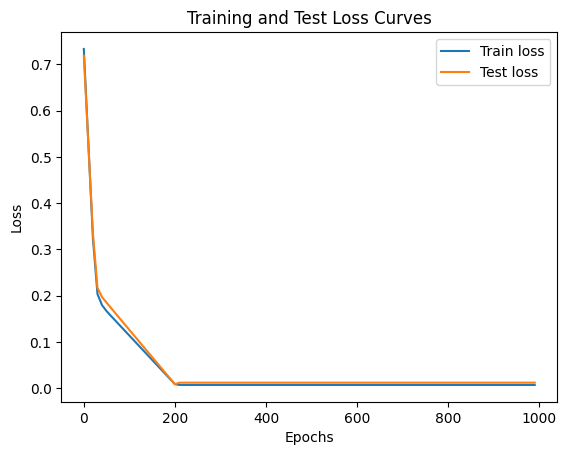

In [150]:
plt.plot(epochs_data, train_loss_values, label="Train loss")
plt.plot(epochs_data, test_loss_values, label="Test loss")
plt.title('Training and Test Loss Curves')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()

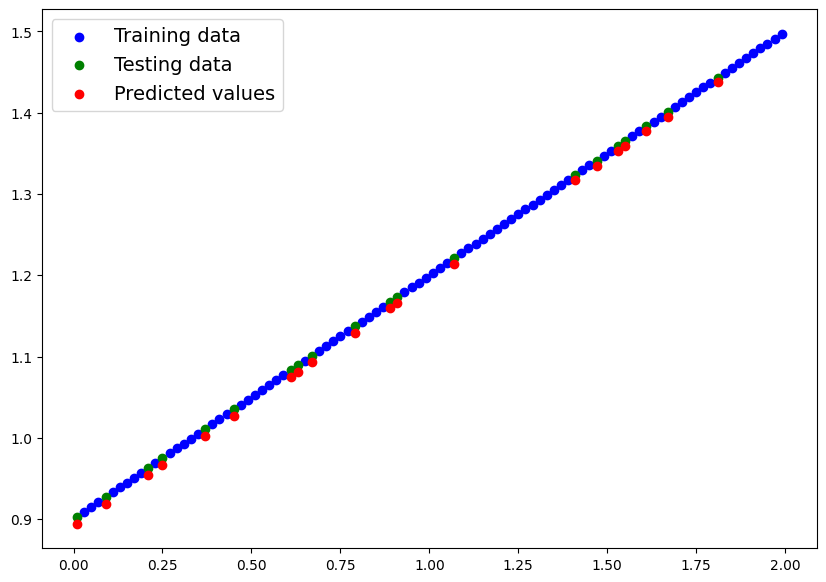

In [151]:
model_0.eval()
with torch.inference_mode():
    predicted_values = model_0(x_test)
plot_predictions(predictions=predicted_values)

In [152]:
pip install pathlib

Note: you may need to restart the kernel to use updated packages.


In [155]:
from pathlib import Path

MODLE_PATH = Path('models')
MODLE_PATH.mkdir(parents=True,exist_ok=True)
MODEL_NAME = '01_linear_model.pth'
MODEL_SAVE_PATH = MODLE_PATH / MODEL_NAME

print(f" Saving model to {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),f=MODEL_SAVE_PATH)


 Saving model to models\01_linear_model.pth


In [156]:
load_model_0 = LinearModel()
load_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

C:\Users\AKSHAY\AppData\Local\Temp\ipykernel_10180\4085968928.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  load_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [157]:
load_model_0.eval()
with torch.inference_mode():
    load_check = load_model_0(x_test)
torch.eq(load_check,predicted_values)

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])